In [97]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# from matplotlib_scalebar.scalebar import ScaleBar

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In this notebook, we will explore behavioral data (ear features) from two mice, `B39` and `B54`, 
reacting to a white noise sound stimulus. Each sound stimulus lasts for two seconds and is played 
around ten (+/- 1) times over the course of a session. Ear responses are decomposed into 3D rotations along the 
pitch, roll, and yaw axis. Can you spot a difference between the two mouse's ear responses?

In [115]:
#Load the Data
B39_ear_responses = pd.read_csv('ear-response-data/B39_Sound_0.csv')
B54_ear_responses = pd.read_csv('ear-response-data/B54_Sound_0.csv')

print(f"B39 Dataframe Dimensions: {B39_ear_responses.shape}")
print(f"B54 Dataframe Dimensions: {B54_ear_responses.shape}")

print("B39:")
B39_ear_responses

B39 Dataframe Dimensions: (60354, 7)
B54 Dataframe Dimensions: (60253, 7)
B39:


,left_yaw,left_pitch,left_roll,right_yaw,right_pitch,right_roll,Sound_0
0,-4.201339,-11.442191,-2.250385,6.474919,6.100838,-1.363937,False
1,-4.267447,-11.690327,-2.009449,6.933251,6.231789,-1.148248,False
2,-4.441324,-11.724432,-2.312710,6.595424,6.215352,-1.471843,False
3,-3.624744,-11.653383,-2.255459,6.419070,6.345819,-1.558113,False
4,-4.466573,-12.521392,-1.989165,6.597797,6.393854,-1.682079,False
...,...,...,...,...,...,...,...
60349,-7.028041,1.879587,-3.350219,13.487891,21.776697,13.284395,False
60350,-6.530474,1.830319,-3.187770,13.736926,22.043346,13.848956,False
60351,-7.085945,1.754364,-3.509427,13.086107,21.251683,14.207655,False
60352,-7.028578,1.667415,-3.466037,13.333516,21.483393,13.894186,False


The `Sound_0` column contains triggers for when the sound stimulus is presented
to the mouse (shown below). Using these trigger timestamps, we want to extract the ear 
responses from one second before the stimulus is presented, through the two second
stimulus period, and one second after the stimulus is presented.


In [111]:
B39_ear_responses[B39_ear_responses['Sound_0']]

,left_yaw,left_pitch,left_roll,right_yaw,right_pitch,right_roll,Sound_0
6394,1.323013,-3.893178,-0.905056,0.722549,-0.388355,-3.316529,True
14386,-3.663452,-9.096214,11.615303,7.156647,-2.846150,-3.715711,True
15385,3.131621,-3.754033,2.039129,6.073529,-0.700223,2.810913,True
18382,6.296514,-1.015509,-0.517587,-2.991090,-4.622793,0.338292,True
24376,-1.009927,8.949886,-3.998420,0.735633,2.259407,3.394418,True
29471,-4.373756,13.433316,-7.667520,0.273575,0.133187,4.293654,True
31369,-5.015373,0.636667,7.443218,13.661748,9.047086,-7.034767,True
34366,1.233351,-8.658041,4.855066,8.625441,9.221193,-16.968855,True
39361,4.331058,0.740170,2.918725,-7.246993,-1.477765,-4.897521,True
44356,10.318730,0.203808,1.342530,1.112835,0.401811,-8.899661,True


In [ ]:
def index_trials(ear_responses_df,
                pre_trial=100, #1 second before trigger
                trial_len=200, #2 second stimulus
                post_trial=100, #1 second after trigger
                ):
    #get the trigger indices
    trigger_indicies = ear_responses_df[ear_responses_df['Sound_0']].index

    #get the specified range between pre_trial and post_trial
    trial_ranges = np.asarray([trigger_indicies - pre_trial, trigger_indicies + trial_len + post_trial]).T

    return trial_ranges, trigger_indicies

trial_ranges, trigger_indices = index_trials(B54_ear_responses)

print(f"Trial Ranges: {trial_ranges}")
print(f"Trigger Indices: {trigger_indices}" )

Trial Ranges: [[ 6388  6788]
 [14380 14780]
 [15379 15779]
 [18376 18776]
 [24370 24770]
 [29364 29764]
 [31363 31763]
 [34360 34760]
 [39355 39755]
 [44349 44749]]
Trigger Indices: Index([6488, 14480, 15479, 18476, 24470, 29464, 31463, 34460, 39455, 44449], dtype='int64')


Great! Now that we have a function to calculate our trial indices, we can use
these to plot each trial's pitch, yaw, and roll variables together as a stacked trace plot.\
We do this by baselining the responses (pretrial mean centered), and plotting each
trial's traces with an offset. By doing this, we can see how movements in the `Pitch`, `Roll`,
and `Yaw` dimensions changes along the same time axis.

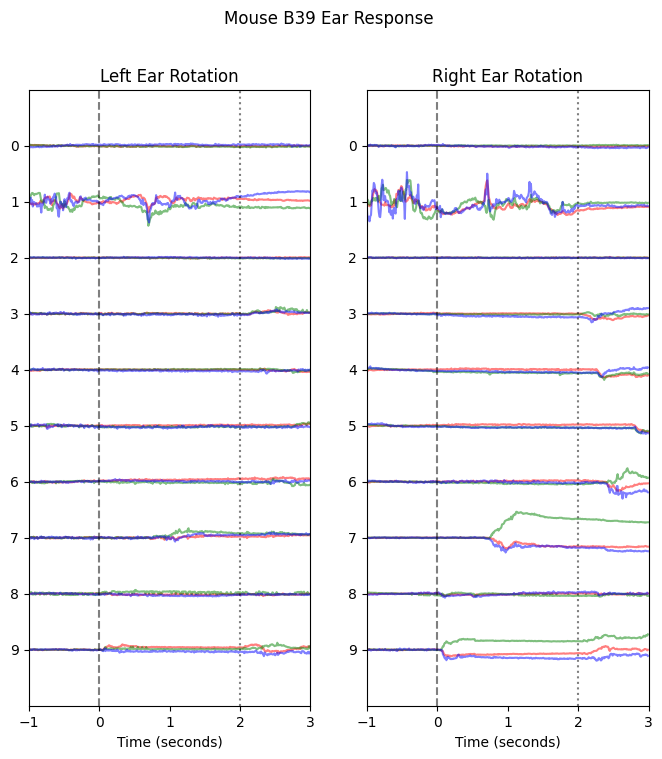

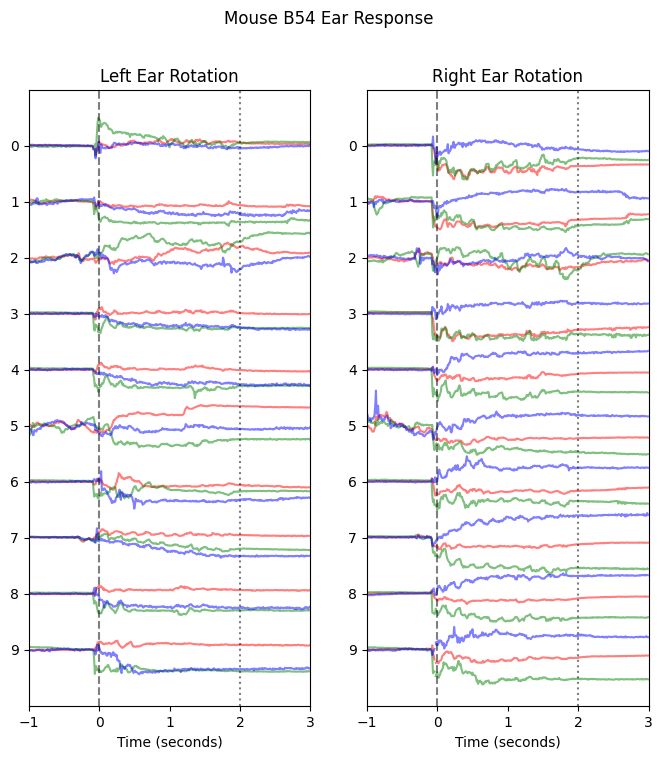

In [108]:
def plot_mouse_ear_traces(ear_responses_df, pre_sound=100, sound_duration=200, post_sound=100, num_sounds=1, mouse_id=None, ears=['left', 'right'], spacing_factor=50):
    #get trial + trigger indices
    trial_indices, trigger_indices = index_trials(ear_responses_df)
    num_trials = trigger_indices.shape[0]
    

    #2 subplots per ear
    fig, axes = plt.subplots(num_sounds, len(ears), figsize=(num_sounds * 8, len(ears) * 4))

    #for every trial
    for ear_num, ear in enumerate(ears):

        for trial_num, trial_idx in enumerate(trial_indices):
            # print(f"Working on Trial {trial_num} : {trial_idx}")

        #extract ear responses per trial
            trial = ear_responses_df.iloc[trial_idx[0] : trial_idx[1]]
        #for each ear in every trial
        
            offset = (num_trials - 1 - trial_num) * spacing_factor #decsending order of trials
            #"basline" ear responses to calculate deviation from prestimulus mean
            baselined_p = trial[f'{ear}_pitch'] - np.nanmean(trial[f'{ear}_pitch'][:pre_sound])
            baselined_r = trial[f'{ear}_roll'] - np.nanmean(trial[f'{ear}_roll'][:pre_sound])
            baselined_y = trial[f'{ear}_yaw'] - np.nanmean(trial[f'{ear}_yaw'][:pre_sound])
            
            #plot traces with offset
            x_axis = (np.arange(-pre_sound, sound_duration + post_sound) / 100)
            axes[ear_num].plot(x_axis, baselined_p + offset, color='red', label='Pitch', alpha=0.5)
            axes[ear_num].plot(x_axis, baselined_r + offset, color='green', label='Roll', alpha=0.5)
            axes[ear_num].plot(x_axis, baselined_y + offset, color='blue', label='Yaw', alpha=0.5)

    
        y_min = - spacing_factor
        y_max = (num_trials- 1) * spacing_factor + spacing_factor


        #formatting
        axes[ear_num].set_ylim(y_min, y_max)
        axes[ear_num].set_xlabel("Time (seconds)")
        axes[ear_num].set_xlim(-pre_sound / 100, (sound_duration + post_sound) / 100)
        y_ticks = [(num_trials - 1 - i) * spacing_factor for i in range(num_trials)]
        axes[ear_num].set_yticks(y_ticks)
        axes[ear_num].set_yticklabels(np.arange(num_trials))


         #plot when the trial starts, and when it ends
        axes[ear_num].axvline(x=0, color="black", linestyle="--", alpha=0.5)
        axes[ear_num].axvline(x=sound_duration / 100, color="black", linestyle=":", alpha=0.5)

        #set titles for each subplot
        ear_labels = ['Left', 'Right']
        axes[ear_num].set_title(f"{ear_labels[ear_num]} Ear Rotation")

    #set figure title
    if mouse_id is not None:
        plt.suptitle(f"Mouse {mouse_id} Ear Response")
    else:
        plt.suptitle(f"Ear Response")

        # scalebar = ScaleBar(
        #         dx=1,
        #         units="deg",
        #         dimension="angle",
        #         fixed_value=5,
        #         width_fraction=0.005,
        #         location="lower right",
        #         scale_loc="right",
        #         rotation="vertical-only",
        #         color="grey",
        #         font_properties={"size": 15},
        #         box_alpha=0.0
        #     )
        #     axes.add_artist(scalebar)

        



plot_mouse_ear_traces(B39_ear_responses, mouse_id='B39')
plot_mouse_ear_traces(B54_ear_responses, mouse_id='B54')

Did you spot a difference? Let's see if this difference is visible when we compare the mean response across trials

In [ ]:
def plot_mean_mouse_ear_traces(ear_responses_df, pre_sound=100, sound_duration=200, post_sound=100, num_sounds=1, mouse_id=None, ears=['left', 'right'], spacing_factor=50):
    #get trial + trigger indices
    trial_indices, trigger_indices = index_trials(ear_responses_df)
    num_trials = trigger_indices.shape[0]
    

    #2 subplots per ear
    fig, axes = plt.subplots(num_sounds, len(ears), figsize=(num_sounds * 8, len(ears) * 4))

    #for every trial
    for ear_num, ear in enumerate(ears):

        for trial_num, trial_idx in enumerate(trial_indices):
            # print(f"Working on Trial {trial_num} : {trial_idx}")

        #extract ear responses per trial
            trial = ear_responses_df.iloc[trial_idx[0] : trial_idx[1]]
        #for each ear in every trial
        
            offset = (num_trials - 1 - trial_num) * spacing_factor #decsending order of trials
            #"basline" ear responses to calculate deviation from prestimulus mean
            baselined_p = trial[f'{ear}_pitch'] - np.nanmean(trial[f'{ear}_pitch'][:pre_sound])
            baselined_r = trial[f'{ear}_roll'] - np.nanmean(trial[f'{ear}_roll'][:pre_sound])
            baselined_y = trial[f'{ear}_yaw'] - np.nanmean(trial[f'{ear}_yaw'][:pre_sound])
            
            #plot traces with offset
            x_axis = (np.arange(-pre_sound, sound_duration + post_sound) / 100)
            axes[ear_num].plot(x_axis, baselined_p + offset, color='red', label='Pitch', alpha=0.5)
            axes[ear_num].plot(x_axis, baselined_r + offset, color='green', label='Roll', alpha=0.5)
            axes[ear_num].plot(x_axis, baselined_y + offset, color='blue', label='Yaw', alpha=0.5)

    
        y_min = - spacing_factor
        y_max = (num_trials- 1) * spacing_factor + spacing_factor


        #formatting
        axes[ear_num].set_ylim(y_min, y_max)
        axes[ear_num].set_xlabel("Time (seconds)")
        axes[ear_num].set_xlim(-pre_sound / 100, (sound_duration + post_sound) / 100)
        y_ticks = [(num_trials - 1 - i) * spacing_factor for i in range(num_trials)]
        axes[ear_num].set_yticks(y_ticks)
        axes[ear_num].set_yticklabels(np.arange(num_trials))


         #plot when the trial starts, and when it ends
        axes[ear_num].axvline(x=0, color="black", linestyle="--", alpha=0.5)
        axes[ear_num].axvline(x=sound_duration / 100, color="black", linestyle=":", alpha=0.5)

        #set titles for each subplot
        ear_labels = ['Left', 'Right']
        axes[ear_num].set_title(f"{ear_labels[ear_num]} Ear Rotation")

    #set figure title
    if mouse_id is not None:
        plt.suptitle(f"Mouse {mouse_id} Ear Response")
    else:
        plt.suptitle(f"Ear Response")

        # scalebar = ScaleBar(
        #         dx=1,
        #         units="deg",
        #         dimension="angle",
        #         fixed_value=5,
        #         width_fraction=0.005,
        #         location="lower right",
        #         scale_loc="right",
        #         rotation="vertical-only",
        #         color="grey",
        #         font_properties={"size": 15},
        #         box_alpha=0.0
        #     )
        #     axes.add_artist(scalebar)